**Reinforcement Learning and Dynamic Optimization.**

Technical University of Crete

Assignment 2 (2025) - Price Optimization Using Bandits

Deadline: 28 Mar, 2025

Student: Karalis Asterinos

AM: 2020030107


Question 1 - User Picks Randomly

The code is very simple regarding its functionality. We set our constants in the begging
and then we execute the MW algorithm step by step as described in the lectures.
We calculate the probabilities of the experts based on their weights and then 
choose probalistically based on them. 
Then we let the user 'choose randomly' between us and the competitor. Based on the fact whether we get reward or not, we update the loss function and then proceed to update all the weights and then repeat the whole process again for the remainder of T.
On each iteration we keep track of various stats such as profit, regret etc.

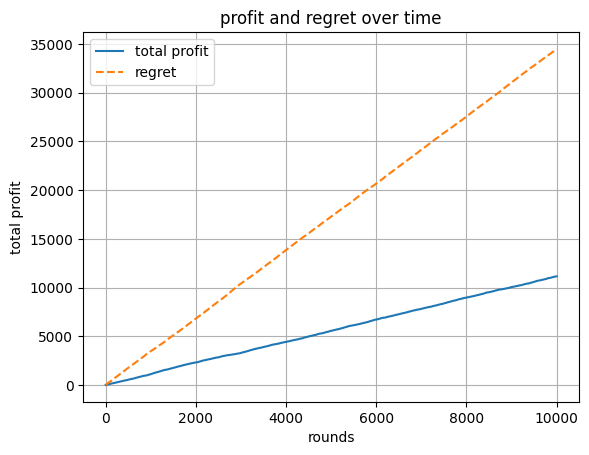

Final weights: [4.93650467e-47 4.44285421e-47 5.48500519e-47 5.48500519e-47
 3.99856879e-47]
Final price probabilities: [0.20274837 0.18247353 0.22527596 0.22527596 0.16422618]
Total reward after T rounds: 11150.941545621716
Total regret after T rounds: 34493.518321843345


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# student id -> 2020030107 -> seed:07

T = 10000  
alpha = 0.5
beta = 1.5
P = np.random.uniform(1.5, 2.5)  

prices = [
    alpha**2 * P,  # p0
    alpha * P,     # p1
    P,             # p2
    beta * P,      # p3
    beta**2 * P    # p4
]

np.random.seed(7)  
weights = np.ones(5)  
eta = 0.1  

rewards = np.zeros(T)
picked_prices = np.zeros(T)
cumulative_rewards = np.zeros(T)
regrets = np.zeros(T)

best_possible_reward = np.max(prices)

for t in range(T):
    #we calculate the probabilities based on the weights and probabilisticaly make a choice.
    probabilities = weights / np.sum(weights)
    chosen_price_index = np.random.choice(5, p=probabilities)
    picked_prices[t] = prices[chosen_price_index]
    
    #get a random price for our competitor
    competitor_price = np.random.uniform(0, 4)
    #in this case, the user selects randomly between us and the competitor.
    user_picked_you = np.random.choice([True, False])
    reward = prices[chosen_price_index] if user_picked_you else 0
    rewards[t] = reward

    #setting the loss function values.
    #this was based on the professor's pdf regarding the experts.
    if reward > 0:
        l_t = 0  #no loss if we actually recieve reward.
    else:
        l_t = 1  #we have loss if we don't get the reward.
    
    #w(t+1) = w(t) * (1 - eta)^l(t)
    #update all weights.
    for i in range(len(weights)):
        weights[i] *= (1 - eta) ** (1 if i == chosen_price_index and reward == 0 else 0)

    cumulative_rewards[t] = np.sum(rewards[:t + 1])
    total_possible_reward = best_possible_reward * (t + 1)
    regrets[t] = total_possible_reward - cumulative_rewards[t]
    #debugging print
    #print(f"Iteration {t+1}:\nWeights: {weights}")

plt.plot(cumulative_rewards, label='total profit')
plt.plot(regrets, label='regret', linestyle='--')
plt.title('profit and regret over time')
plt.xlabel('rounds')
plt.ylabel('total profit')
plt.grid(True)
plt.legend()
plt.show()

final_probabilities = weights / np.sum(weights)
print("Final weights:", weights)
print("Final price probabilities:", final_probabilities)
print("Total reward after T rounds:", np.sum(rewards))
print("Total regret after T rounds:", regrets[-1])


Question 2 - User Becomes Smart:

The code is basically the same as in Question 1. 
However, in this version, after T/4 rounds have passed, the user will pick the lowest price offered instead of choosing randomly (if statements).

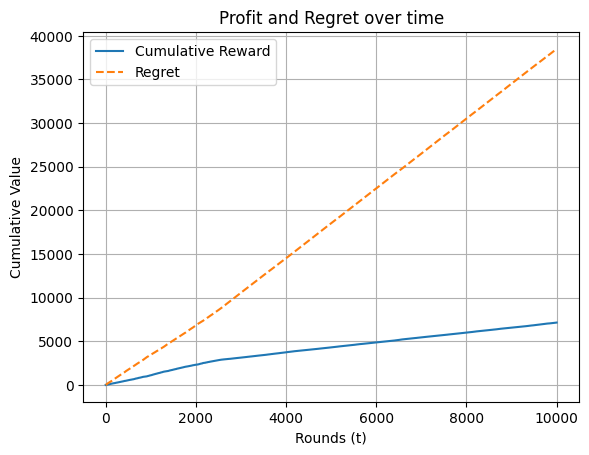

Final weights: [6.11965086e-33 2.13379032e-33 9.18526764e-34 6.69606011e-34
 4.39328504e-34]
Final price probabilities: [0.59524452 0.20754893 0.08934301 0.06513105 0.04273248]
Total reward after T rounds: 7144.879451253864
Total regret after T rounds: 38499.580416211196


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# student id -> 2020030107 -> seed:07

T = 10000
alpha = 0.5
beta = 1.5
P = np.random.uniform(1.5, 2.5)  

prices = [
    alpha**2 * P,  # p0
    alpha * P,     # p1
    P,             # p2
    beta * P,      # p3
    beta**2 * P    # p4
]

np.random.seed(7)  
weights = np.ones(5)  
eta = 0.1  

rewards = np.zeros(T)
picked_prices = np.zeros(T)
cumulative_rewards = np.zeros(T)
regrets = np.zeros(T)

best_possible_reward = np.max(prices)
naive_rounds = T // 4

for t in range(T):
    #we calculate the probabilities based on the weights and probabilisticaly make a choice.
    probabilities = weights / np.sum(weights)
    chosen_price_index = np.random.choice(5, p=probabilities)
    picked_prices[t] = prices[chosen_price_index]
    
    #for the first 1/4 of the T, we have the previous setup
    if t < naive_rounds:
        #get a random price for our competitor
        competitor_price = np.random.uniform(0, 4)
        user_picked_you = np.random.choice([True, False])  # Random choice
        reward = prices[chosen_price_index] if user_picked_you else 0
    else:
        #now, the user will prefer the lowest price offered.
        #get a random price for our competitor
        competitor_price = np.random.uniform(0, 4)
        if prices[chosen_price_index] <= competitor_price:
            reward = prices[chosen_price_index]
        else:
            reward = 0

    rewards[t] = reward
    
    #setting the loss function values.
    #this was based on the professor's pdf regarding the experts.
    if reward > 0:
        l_t = 0  #no loss if we actually recieve reward.
    else:
        l_t = 1  #we have loss if we don't get the reward.

    #w(t+1) = w(t) * (1 - eta)^l(t)
    #update all weights.
    for i in range(len(weights)):
        weights[i] *= (1 - eta) ** (1 if i == chosen_price_index and reward == 0 else 0)
    
    cumulative_rewards[t] = np.sum(rewards[:t + 1])
    total_possible_reward = best_possible_reward * (t + 1)
    regrets[t] = total_possible_reward - cumulative_rewards[t]
    #debugging print to check weight prices
    #print(f"Iteration {t+1}:\nWeights: {weights}")

plt.plot(cumulative_rewards, label='Cumulative Reward')
plt.plot(regrets, label='Regret', linestyle='--')
plt.title('Profit and Regret over time')
plt.xlabel('Rounds (t)')
plt.ylabel('Cumulative Value')
plt.grid(True)
plt.legend()
plt.show()

final_probabilities = weights / np.sum(weights)
print("Final weights:", weights)
print("Final price probabilities:", final_probabilities)
print("Total reward after T rounds:", np.sum(rewards))
print("Total regret after T rounds:", regrets[-1])


Results and analysis:

After running both simulations for T=10000 we notice that: 

In the first scenario we gain singifically more rewards than in the second one. 
This is to be expected since, although we don't know it, the only way to get reward in the first scenario is if the user chooses us. A good strategy here would be to always offer our highest price. However since the algorithm 'doens't know' this it attemps to adjust to what is happening. 

On the second simulation we actaully notice a relative steady rise of the reward we receive up until the naive period ends at T/4 (round 2500). Once the behaivor of the user changes we notice a loss in reward as it flattens bit and as the algorithm adjusts, it rises again. Now that user prefers the lowest price offered we can no longer obtain as much reward as we would in the first scenario.